# Smiley Sample With Circular Input Wave

Minimal example: apply a smiley sample to a circular Gaussian input wave and visualise the resulting field.

## Setup

Enable JAX float64 and import only what is needed for this simple sample demo.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"

import jax
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

from temgym_core.components import Detector, sample_interpolant
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.gaussian import FreeSpacePropagator
from temgym_core.run import run_to_end_vmapped
from temgym_core.source import circular_input_wave

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)

W0317 22:24:00.166073  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


JAX backend: gpu


In [2]:
def smiley(size):
    '''
    Smiley face test object from https://doi.org/10.1093/micmic/ozad021
    '''
    obj = np.ones((size, size), dtype=np.complex64)
    y, x = np.ogrid[-size // 2:size // 2, -size // 2:size // 2]

    outline = (((y * 1.2) ** 2 + x**2) > (110 / 256 * size) ** 2) & (
        ((y * 1.2) ** 2 + x**2) < (120 / 256 * size) ** 2
    )
    obj[outline] = 0.0

    left_eye = ((y + 40 / 256 * size) ** 2 + (x + 40 / 256 * size) ** 2) < (20 / 256 * size) ** 2
    obj[left_eye] = 0
    right_eye = (np.abs(y + 40 / 256 * size) < 15 / 256 * size) & (
        np.abs(x - 40 / 256 * size) < 30 / 256 * size
    )
    obj[right_eye] = 0

    nose = (y + 20 / 256 * size + x > 0) & (x < 0) & (y < 10 / 256 * size)
    obj[nose] = (0.05j * x + 0.05j * y)[nose]

    mouth = (((y * 1) ** 2 + x**2) > (50 / 256 * size) ** 2) & (
        ((y * 1) ** 2 + x**2) < (70 / 256 * size) ** 2
    ) & (y > 20 / 256 * size)
    obj[mouth] = 0

    tongue = (((y - 50 / 256 * size) ** 2 + (x - 50 / 256 * size) ** 2) < (20 / 256 * size) ** 2) & (
        (y**2 + x**2) > (70 / 256 * size) ** 2
    )
    obj[tongue] = 0

    signature_wave = np.exp(1j * (3 * y + 7 * x) * 2 * np.pi / size)
    obj += 0.3 * signature_wave - 0.3
    return obj


def axes_from_width(size, width_m):
    step = width_m / size
    coords = (np.arange(size) - 0.5 * (size - 1)) * step
    return coords, coords

In [3]:
size = 256
sample_width_m = 3.0e-6
voltage = 200e3
propagation_distance = 1000e-6

x_coords, y_coords = axes_from_width(size, sample_width_m)
smiley_image = smiley(size)

# Build a smooth, bounded complex transmission to keep Gaussian-action derivatives stable.
smiley_amp_raw = np.abs(smiley_image)
smiley_amp = smiley_amp_raw / (np.max(smiley_amp_raw) + 1e-12)
smiley_phase = 1e-12 * np.angle(smiley_image)
smiley_complex = smiley_amp * np.exp(1j * smiley_phase)

sample = sample_interpolant(
    sample=smiley_complex,
    x_coords=x_coords,
    y_coords=y_coords,
    z=0.0,
    method="cubic",
    extrap=1.0,
)

pixel_size = sample_width_m / size
grid_0 = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(size, size),
)
grid_1 = Detector(
    z=propagation_distance,
    pixel_size=(pixel_size, pixel_size),
    shape=(size, size),
)

# Denser Gaussian basis for smaller beamlets and cleaner object sampling.
rays_in = circular_input_wave(
    aperture_radius=1e-6,
    waist=1e-8,
    voltage=voltage,
    z0=0.0,
    overlap_factor=2.8,
)

rays_after_sample = run_to_end_vmapped(rays_in, (sample,))
rays_after_prop = run_to_end_vmapped(
    rays_after_sample,
    (grid_1,),
    propagator=FreeSpacePropagator(),
)

field_0 = evaluate_gaussians_gpu_kernel_wrapper(rays_after_sample, grid_0)
field_1 = evaluate_gaussians_gpu_kernel_wrapper(rays_after_prop, grid_1)

extent_um = tuple(float(v) * 1e6 for v in grid_0.extent)

print("Simulation complete.")
print("Num gaussians:", np.asarray(rays_in.x).size)
print("Input amplitude map range:", float(np.min(smiley_amp)), float(np.max(smiley_amp)))
print("Applied transmission range:", float(np.min(smiley_amp)), float(np.max(smiley_amp)))
print("Phase peak (rad):", 1e-12)
print("field_0 finite fraction:", np.isfinite(np.asarray(field_0)).mean())
print("field_1 finite fraction:", np.isfinite(np.asarray(field_1)).mean())

W0317 22:25:03.642602  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.732469  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.819048  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.877010  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.922799  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.943764  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:03.980333  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:04.018641  435926 sol_gpu_cost_model

Simulation complete.
Num gaussians: 246301
Input amplitude map range: 0.0 1.0
Applied transmission range: 0.0 1.0
Phase peak (rad): 1e-12
field_0 finite fraction: 1.0
field_1 finite fraction: 1.0


W0317 22:25:09.834276  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:09.875663  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:09.909092  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:09.939116  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:09.976960  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.
W0317 22:25:10.001240  435926 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA GH200 144G HBM3e. Using default config.


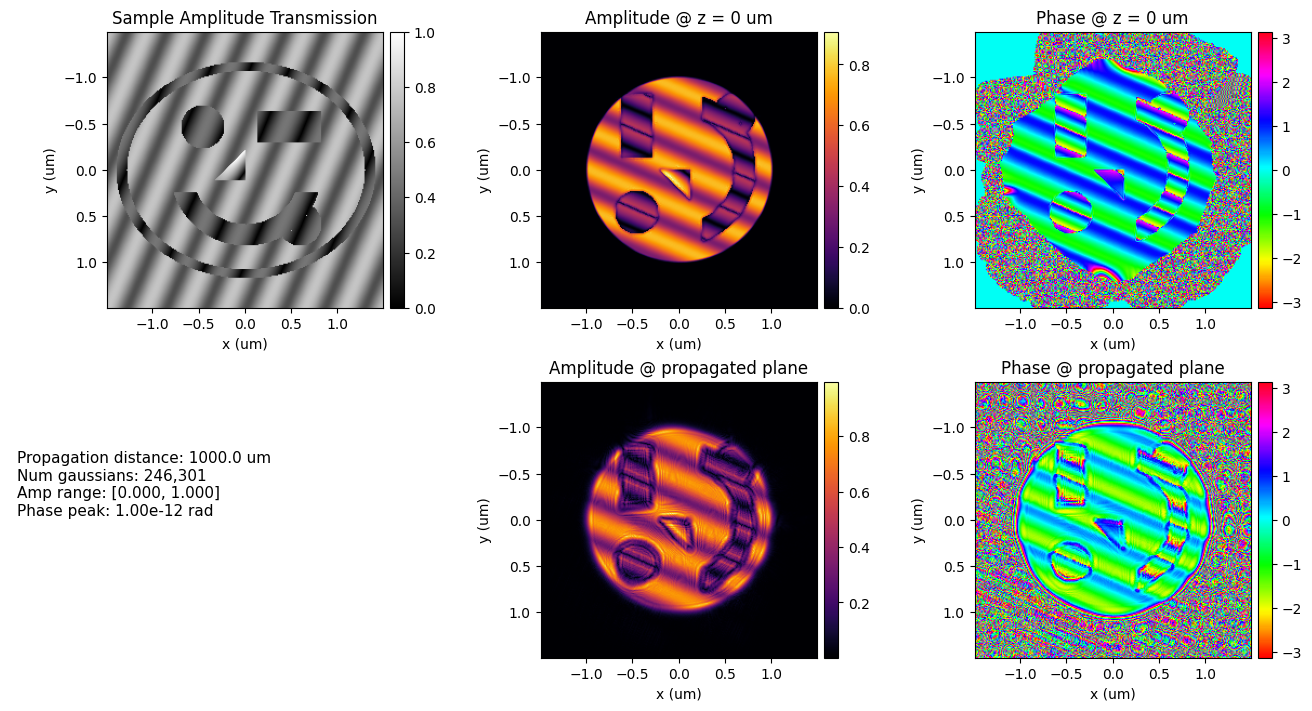

: 

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)

im0 = axs[0, 0].imshow(smiley_amp, extent=extent_um, cmap="gray")
axs[0, 0].set_title("Sample Amplitude Transmission")
axs[0, 0].set_xlabel("x (um)")
axs[0, 0].set_ylabel("y (um)")
plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.02)

im1 = axs[0, 1].imshow(np.abs(field_0), extent=extent_um, cmap="inferno")
axs[0, 1].set_title("Amplitude @ z = 0 um")
axs[0, 1].set_xlabel("x (um)")
axs[0, 1].set_ylabel("y (um)")
plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.02)

im2 = axs[0, 2].imshow(np.angle(field_0), extent=extent_um, cmap="hsv", vmin=-np.pi, vmax=np.pi)
axs[0, 2].set_title("Phase @ z = 0 um")
axs[0, 2].set_xlabel("x (um)")
axs[0, 2].set_ylabel("y (um)")
plt.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.02)

axs[1, 0].axis("off")
axs[1, 0].text(
    0.02,
    0.75,
    f"Propagation distance: {propagation_distance * 1e6:.1f} um\nNum gaussians: {np.asarray(rays_in.x).size:,}\nAmp range: [{np.min(smiley_amp):.3f}, {np.max(smiley_amp):.3f}]\nPhase peak: {1e-12:.2e} rad\n",
    transform=axs[1, 0].transAxes,
    fontsize=11,
    verticalalignment="top",
)

im3 = axs[1, 1].imshow(np.abs(field_1), extent=extent_um, cmap="inferno")
axs[1, 1].set_title("Amplitude @ propagated plane")
axs[1, 1].set_xlabel("x (um)")
axs[1, 1].set_ylabel("y (um)")
plt.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.02)

im4 = axs[1, 2].imshow(np.angle(field_1), extent=extent_um, cmap="hsv", vmin=-np.pi, vmax=np.pi)
axs[1, 2].set_title("Phase @ propagated plane")
axs[1, 2].set_xlabel("x (um)")
axs[1, 2].set_ylabel("y (um)")
plt.colorbar(im4, ax=axs[1, 2], fraction=0.046, pad=0.02)

plt.show()